Name : Fateh Noor <br>
CMS-ID: 023-24-0110 <br>
Section: D

### Part 1 — Dataset, Problem & Feature/Target Identification

## 1. Problem Definition

The objective of this project is to predict the sale price of residential houses in Ames, Iowa using their numerical and categorical features. Since the target variable, SalePrice, is a continuous numerical value, this is a regression problem. A Multiple Linear Regression model is used to learn the relationship between house features and their sale prices.

In [177]:
#task1
import pandas as pd 
import numpy as np
df=pd.read_csv("train.csv")
print("Shape of data: ",df.shape)
print("DTypes of data: ",df.dtypes)
print("First few rows: ",df.head())
print("Summary of data: ",df.describe())

Shape of data:  (1460, 81)
DTypes of data:  Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
Street            object
Alley             object
LotShape          object
LandContour       object
Utilities         object
LotConfig         object
LandSlope         object
Neighborhood      object
Condition1        object
Condition2        object
BldgType          object
HouseStyle        object
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
RoofStyle         object
RoofMatl          object
Exterior1st       object
Exterior2nd       object
MasVnrType        object
MasVnrArea       float64
ExterQual         object
ExterCond         object
Foundation        object
BsmtQual          object
BsmtCond          object
BsmtExposure      object
BsmtFinType1      object
BsmtFinSF1         int64
BsmtFinType2      object
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalB

In [178]:
#task2
numerical_features = df.select_dtypes(include='number').columns
categorical_features = df.select_dtypes(include='object').columns
print("Numerical Features:")
print(numerical_features)
print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

Categorical Features:
Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFin

## Dependent Variable
The dependent variable is **SalePrice**.

## Independent Variables

### Numerical Features
- MSSubClass
- LotFrontage
- LotArea
- OverallQual
- OverallCond
- ...

### Categorical Features
- MSZoning
- Street
- Alley
- LotShape
- ...

### Task 3
This is a regression problem because the dependent variable, SalePrice, is a continuous numerical value rather than a category. Therefore, the model will be evaluated using regression metrics such as MAE, MSE, RMSE, and R² instead of classification metrics such as accuracy, precision, and recall.

### Part 2 — Data Preparation & Train/Test Split

In [179]:
y=df['SalePrice']
x = df[
    [
        'OverallQual',
        'GrLivArea',
        'GarageCars',
        'TotalBsmtSF',
        'YearBuilt',
        'MSZoning',
        'Neighborhood',
        'HouseStyle',
        'KitchenQual',
        'GarageFinish'
    ]
]
x=pd.get_dummies(x,columns=x.select_dtypes(include='object').columns,drop_first=True)
print(x.shape)

(1460, 45)


### Encoding Method

I used One-Hot Encoding for all categorical features because these
categories do not have a natural numerical order. One-Hot Encoding
converts each category into a separate binary (0/1) column without
introducing an artificial relationship between categories.

The numerical features were kept in their original numeric form
because they are already represented as numbers suitable for regression.

In [180]:
#task5
print("Missing values: ",x.isnull().sum().sum())

Missing values:  0


In [181]:
#task6
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,
                              test_size=0.2,
                              random_state=42)
print("Shape of x_train: ",x_train.shape)
print("Shape of x_test: ",x_test.shape)
print("Shape of y_train: ",y_train.shape)
print("Shape of y_test: ",y_test.shape)

Shape of x_train:  (1168, 45)
Shape of x_test:  (292, 45)
Shape of y_train:  (1168,)
Shape of y_test:  (292,)


### Part 3 — Linear Regression & Predictions

In [182]:
#task7
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
#task8
y_pred=lr.predict(x_test)
print(y_pred[:10].round(2))
print(y_test[:10])

[137881.3  317827.44 111459.96 166135.24 316761.46  72094.77 232395.78
 145363.14  71739.28 114440.5 ]
892     154500
1105    325000
413     115000
522     159000
1036    315500
614      75500
218     311500
1160    146000
649      84500
887     135500
Name: SalePrice, dtype: int64


| House No. | Actual price | Predicted Price |
|---:|---:|---:|
|1|154500|137881.3|
|2|325000|317827.44|
|3|115000|111459.96|
|4|159000|166135.24|
|5|315500|316761.46|
|6|75500|72094.77|
|7|311500|232395.78|
|8|146000|145363.14|
|9|84500|71739.28|
|10|135500|114440.5|

### Part 4 — Coefficients & Intercept

In [ ]:
#task9
import pandas as pd
from IPython.display import display
print("Intercept:", lr.intercept_.round(2))
coef_table = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": lr.coef_
})
coef_table["Interpretation"] = [
    f"Each 1-unit increase in {feature} is associated with a "
    f"{'price increase' if coef > 0 else 'price decrease'} of approximately "
    f"{abs(coef):.2f}, holding other features constant."
    for feature, coef in zip(x.columns, lr.coef_)
]
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
display(coef_table)

Intercept: -372244.96


,Feature,Coefficient,Interpretation
0,OverallQual,12764.336348,"Each 1-unit increase in OverallQual is associated with a price increase of approximately 12764.34, holding other features constant."
1,GrLivArea,54.497863,"Each 1-unit increase in GrLivArea is associated with a price increase of approximately 54.50, holding other features constant."
2,GarageCars,13138.771680,"Each 1-unit increase in GarageCars is associated with a price increase of approximately 13138.77, holding other features constant."
3,TotalBsmtSF,6.113969,"Each 1-unit increase in TotalBsmtSF is associated with a price increase of approximately 6.11, holding other features constant."
4,YearBuilt,177.747659,"Each 1-unit increase in YearBuilt is associated with a price increase of approximately 177.75, holding other features constant."
5,MSZoning_FV,30395.202709,"Each 1-unit increase in MSZoning_FV is associated with a price increase of approximately 30395.20, holding other features constant."
6,MSZoning_RH,19599.342734,"Each 1-unit increase in MSZoning_RH is associated with a price increase of approximately 19599.34, holding other features constant."
7,MSZoning_RL,30614.154576,"Each 1-unit increase in MSZoning_RL is associated with a price increase of approximately 30614.15, holding other features constant."
8,MSZoning_RM,19516.983185,"Each 1-unit increase in MSZoning_RM is associated with a price increase of approximately 19516.98, holding other features constant."
9,Neighborhood_Blueste,9450.359252,"Each 1-unit increase in Neighborhood_Blueste is associated with a price increase of approximately 9450.36, holding other features constant."


### Task 10
No, the intercept does not have a sensible real-world interpretation for this dataset. The intercept is -372,244.96, which represents the predicted SalePrice when all independent variables are zero. A house with all these features equal to zero is not a realistic situation, and a negative house price is also not meaningful in this context. Therefore, the intercept should not be interpreted as an actual house price.

### Part 5 — Residuals & Regression Metrics

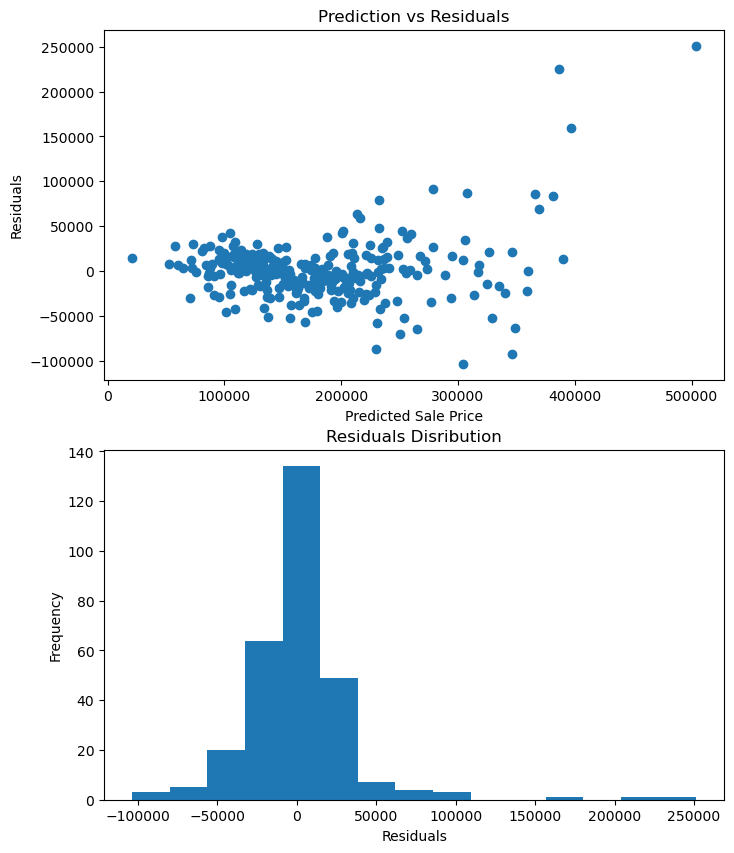

In [ ]:
#task11
import matplotlib.pyplot as plt
res=y_test-y_pred
plt.figure(figsize=(8,10))
plt.subplot(2,1,1)
plt.scatter(y_pred,res)
plt.xlabel("Predicted Sale Price")
plt.ylabel("Residuals")
plt.title("Prediction vs Residuals")
plt.subplot(2,1,2)
plt.hist(res,bins=15)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residuals Disribution")
plt.tight_layout
plt.show()

The residuals are mostly centered around zero, but they are not completely randomly scattered. The spread increases for higher predicted prices and there are some large outliers, indicating non-constant variance and possible heteroscedasticity.

In [ ]:
#task12
from sklearn.metrics import (mean_absolute_error,
                            mean_squared_error,
                            root_mean_squared_error,
                            r2_score)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=root_mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("Mean Absolute error: ",round(mae,2))
print("Mean Squared error: ",round(mse,2))
print("Root Mean Squared error: ",round(rmse,2))
print("R2 error: ",round(r2,2))

Mean Absolute error:  20951.24
Mean Squared error:  1178207907.22
Root Mean Squared error:  34325.03
R2 error:  0.85


| Metric | Value |
|---:|---:|
| Mean Absolute Error | 20951.24 |
| Mean Squared Error | 1178207907.22 |
| Root Mean Squared Error | 34325.03 |
| R2 Error | 0.85 |

### Task 13
MAE tells us the average absolute difference between predicted and actual prices. MSE squares the errors and therefore gives more weight to large errors. RMSE is the square root of MSE and expresses the typical prediction error in the original price units. R² tells us how much of the variation in house prices is explained by the model. For a non-technical stakeholder, I would show MAE because it is the easiest to understand and is expressed directly in the same units as the house price.

### Part 6 — Training vs. Testing & Generalization

In [ ]:
#task14
pred_train=lr.predict(x_train)
mae=mean_absolute_error(y_train,pred_train)
mse=mean_squared_error(y_train,pred_train)
rmse=root_mean_squared_error(y_train,pred_train)
r2=r2_score(y_train,pred_train)
print("Mean Absolute error: ",round(mae,2))
print("Mean Squared error: ",round(mse,2))
print("Root Mean Squared error: ",round(rmse,2))
print("R2 error: ",round(r2,2))

Mean Absolute error:  20414.13
Mean Squared error:  1039429093.99
Root Mean Squared error:  32240.18
R2 error:  0.83


| Metric |     Training Set |         Test Set |
| ------ | ---------------: | ---------------: |
| MAE    |        20,414.13 |        20,951.24 |
| MSE    | 1,039,429,093.99 | 1,178,207,907.22 |
| RMSE   |        32,240.18 |        34,325.03 |
| R²     |             0.83 |             0.85 |


### Task 15
There is no large gap between the training and testing performance. The MAE, MSE, and RMSE are slightly higher on the test set, while the R² values are very close (0.83 for training and 0.85 for testing).

A large gap between training and testing performance would usually suggest overfitting, meaning the model performs very well on training data but poorly on unseen data. In this case, the small difference suggests that the model is generalizing reasonably well to the test data and there is no strong indication of overfitting.

### Part 7 — Final Model Analysis, Conclusion & Kaggle Submission

### Task 16
The 2–3 features with the largest coefficient magnitudes are Neighborhood_NoRidge (82,547.26), Neighborhood_StoneBr (68,267.31), and Neighborhood_NridgHt (64,532.38). These have the largest absolute coefficients in the fitted model. However, coefficient magnitude alone does not necessarily indicate overall feature importance because the features have different units and scales, and categorical variables are dummy-coded relative to reference categories.

### Task 17
The Linear Regression model predicts house prices reasonably well, achieving an R² of 0.85 on the test set, meaning it explains about 85% of the variation in house prices. The MAE of approximately 20,951 is the most useful metric for a non-technical stakeholder because it directly shows the average prediction error in the same units as the house price. Among the features, Neighborhood_NoRidge has the largest coefficient magnitude at approximately 82,547, although coefficient magnitude should be interpreted carefully because features have different scales and categorical variables are measured relative to a reference category. Linear Regression assumes a linear relationship between the predictors and house prices, which may not fully capture the complex relationships in this dataset. The residual plots also show increasing spread and some large outliers, suggesting non-constant variance and limitations of the linear model. As a next step, I would try transforming the target variable, handling outliers, and comparing the results with models such as Ridge/Lasso Regression or tree-based models.

In [207]:
#task18
test=pd.read_csv("test.csv")
test_x = test[
    [
        'OverallQual',
        'GrLivArea',
        'GarageCars',
        'TotalBsmtSF',
        'YearBuilt',
        'MSZoning',
        'Neighborhood',
        'HouseStyle',
        'KitchenQual',
        'GarageFinish'
    ]
]
categorical_features=test_x.select_dtypes(include="object").columns
test_x=pd.get_dummies(test_x,categorical_features,drop_first=True)
test_x=test_x.reindex(columns=x.columns,fill_value=0)
numerical_features=test_x.select_dtypes(include='number').columns
test_x[numerical_features]=test_x[numerical_features].fillna(test_x[numerical_features].median())
test_pred=lr.predict(test_x).round(2)
submission=pd.DataFrame({
    "Id":test["Id"],
    "SalePrice":test_pred
})
submission.to_csv("submission.csv",index=False)

### Task 19
Public Leaderboard Score: 0.16646<br>
Rank: 2679

Reflection:
Seeing my model’s performance on the public leaderboard was exciting because it showed how my work compared with thousands of real submissions. It was a valuable experience to see the results of my Linear Regression model evaluated on unseen competition data.